# Sneaker-Resale -- does StockX really beat the stock market?
### The 'sneakers are an asset class' pitch, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

You have heard it since 2017: reselling sneakers on **StockX** or **GOAT** is an alternative asset class that *beats stocks* -- double-digit returns, smaller drawdowns, the 'stock market of things.' This notebook asks the only questions that matter: **did the sneaker market actually out-return the S&P 500?** And if its risk-adjusted numbers look so good, **are they real -- or an accounting illusion?**

> **This is the plain-language layer.** Want the t-stats, the Newey-West HAC standard error, and the appraisal-unsmoothing? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sneaker_resale import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=18, year_start=2007, year_end=2024,
    sneaker_cagr_pct=7.0, gspc_cagr_pct=8.2,
    sneaker_mean_pct=7.5, sneaker_vol_pct=10.6,
    gspc_mean_pct=9.9, gspc_vol_pct=17.9,
    excess_mean_pct=-2.4, excess_t_ols=-0.567, excess_p_ols=0.5781, excess_t_hac=-0.58,
    sneaker_sharpe=0.71, gspc_sharpe=0.55,
    ar1_rho=0.63, unsmoothed_vol_pct=23.1, unsmoothed_sharpe=0.29,
    net_sneaker_mean_pct=4.5,
    strat_cagr_pct=9.3, bah_gspc_cagr_pct=8.2, trend_shortfall_pp=1.03,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did sneakers out-return the S&P? | **No.** Sneaker CAGR **+7.0%** vs S&P **+8.2%**; the average annual *excess* return is **−2.4%** -- sneakers *underperformed*. |
| But the Sharpe looks higher (0.71 vs 0.55)? | An **illusion.** The index is smoothed (annual, infrequent appraisals). Undo the smoothing and its true volatility is **23%** (more than the S&P's 18%); the Sharpe falls to **0.29**. |
| Could you actually buy it? | **No vehicle.** You'd resell physical pairs: ~10–15% marketplace fees, authentication, storage, no shorting. Net ~**+4.5%/yr**. |
| Was the boom real? | Yes -- and so was the **bust** (2022–2024). Buying near the 2021 peak was brutal. |

> Sneakers are fun. As an *asset class that beats stocks*, the claim does not survive contact with the data.

## 1 - The claim

> *"The sneaker resale market is a real alternative asset. On StockX it behaves like a stock exchange -- bids, asks, a live price -- and it has returned double digits with lower volatility than equities. Sneakers beat stocks."*

The marketplaces leaned into the framing on purpose (StockX literally borrowed exchange language). The press ran with it. We test it against the boring benchmark every alternative asset must clear: the **S&P 500**.

## 2 - So what?

If it were true -- a liquid, investable sneaker index that out-returns equities at lower risk -- it would be a genuine free lunch, and every endowment would own some. The interesting question is *why the numbers look so good*: is there real outperformance, or is the attractive risk profile manufactured by how the index is priced?

## 3 - How would we even know?

Three traps to avoid:

1. **Return, not vibes.** Compare the sneaker index's annual return to the S&P, year by year, and test the *average difference* against zero.
2. **Smoothed prices lie about risk.** Appraisal-style indices (private real estate, hedge-fund NAVs, and yes -- collectibles) report infrequent, lagged marks. That makes them look calm. The tell is high year-to-year **autocorrelation**; the fix is to *unsmooth* the series.
3. **Can you actually buy it?** A backtest of an *index you cannot trade* is a fantasy. Physical resale has brutal frictions and no short side.

We test all of this on **^GSPC** (S&P 500 price index) from 2007 to 2024, matched to our curated annual sneaker-resale index (18 paired years).

## 4 - The teardown -- let's actually look

**First, meet the data:** the curated sneaker-resale index (hardcoded in `data.py`) paired with the S&P 500 calendar-year return.

In [2]:
sn = data.sneaker_index()
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    s = st.summarize(df)
else:
    df, s = None, R

print('Sneaker index: 2006-2024 (19 levels, 18 annual returns)')
print(f"Paired years vs S&P: {s['n']} ({R['year_start']}-{R['year_end']})")
print()
print(f"Sneaker CAGR: {s['sneaker_cagr_pct']:+.1f}%/yr   S&P CAGR: {s['gspc_cagr_pct']:+.1f}%/yr")
print(f"Average annual EXCESS (sneaker - S&P): {s['excess_mean_pct']:+.1f}%/yr")

Sneaker index: 2006-2024 (19 levels, 18 annual returns)
Paired years vs S&P: 18 (2007-2024)

Sneaker CAGR: +7.0%/yr   S&P CAGR: +8.2%/yr
Average annual EXCESS (sneaker - S&P): -2.4%/yr


**The boom and the bust -- the sneaker index level over time.**

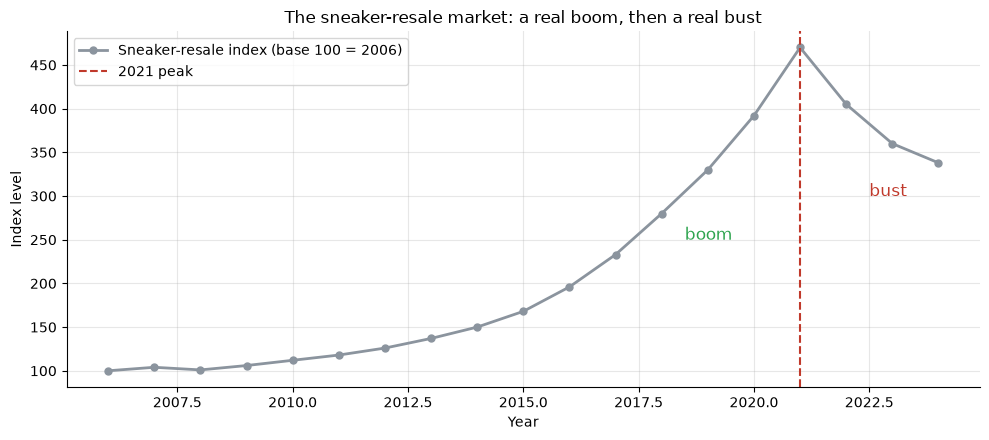

Peak (2021): 470   |   2024: 338   (gave back 28% of the peak)


In [3]:
lv = sn.set_index('year')['level']
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(lv.index, lv.values, 'o-', c=GREY, lw=2, ms=5, label='Sneaker-resale index (base 100 = 2006)')
ax.axvline(2021, ls='--', c=RED, lw=1.5, label='2021 peak')
ax.annotate('boom', (2018.5, 250), color=GREEN, fontsize=12)
ax.annotate('bust', (2022.5, 300), color=RED, fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Index level')
ax.set_title('The sneaker-resale market: a real boom, then a real bust')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Peak (2021): {lv[2021]:.0f}   |   2024: {lv[2024]:.0f}   '
      f'(gave back {(1-lv[2024]/lv[2021])*100:.0f}% of the peak)')

The market really did explode once StockX and GOAT industrialised resale (2016–2021), and it really did crater afterwards (2022–2024) as premiums compressed and the marketplaces cut staff. Anyone who bought the hype near the 2021 peak ate a painful drawdown.

**Did it beat stocks? Sneaker vs S&P, year by year.**

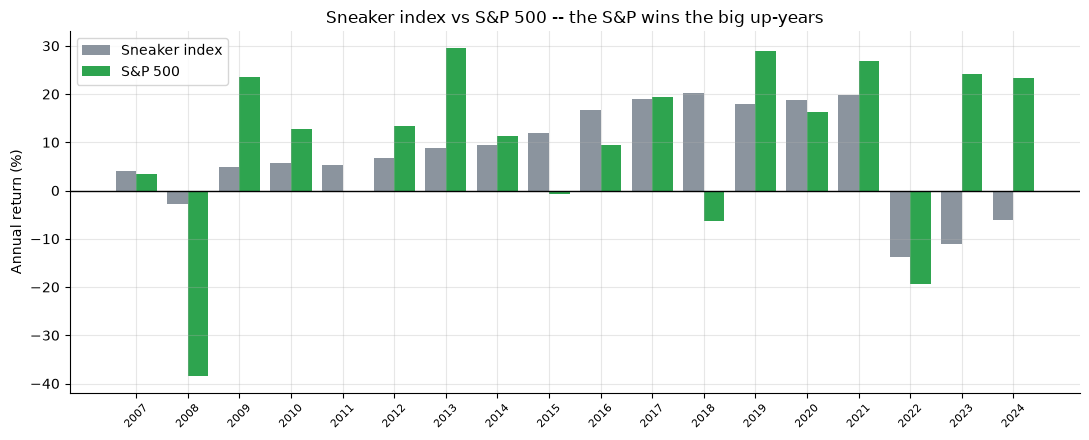

Sneaker mean: +7.5%   |   S&P mean: +9.9%
The sneaker index is calmer year to year -- hold that thought.


In [4]:
if HAVE_REAL:
    yrs = df['year'].values
    snr = df['sneaker_return'].values * 100
    gsr = df['gspc_return'].values * 100
else:
    rng = np.random.default_rng(276)
    yrs = np.arange(R['year_start'], R['year_end']+1)
    snr = rng.normal(R['sneaker_mean_pct'], R['sneaker_vol_pct'], R['n'])
    gsr = rng.normal(R['gspc_mean_pct'], R['gspc_vol_pct'], R['n'])

x = np.arange(len(yrs)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x-w/2, snr, w, color=GREY, label='Sneaker index')
ax.bar(x+w/2, gsr, w, color=GREEN, label='S&P 500')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(yrs, rotation=45, fontsize=8)
ax.set_ylabel('Annual return (%)')
ax.set_title('Sneaker index vs S&P 500 -- the S&P wins the big up-years')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Sneaker mean: {snr.mean():+.1f}%   |   S&P mean: {gsr.mean():+.1f}%")
print('The sneaker index is calmer year to year -- hold that thought.')

The sneaker bars are *smaller* in both directions -- it looks like a calmer, lower-risk asset. That calmness is exactly what makes its Sharpe ratio look great. But is the calmness real?

**The Sharpe illusion -- what happens when we undo the smoothing.**

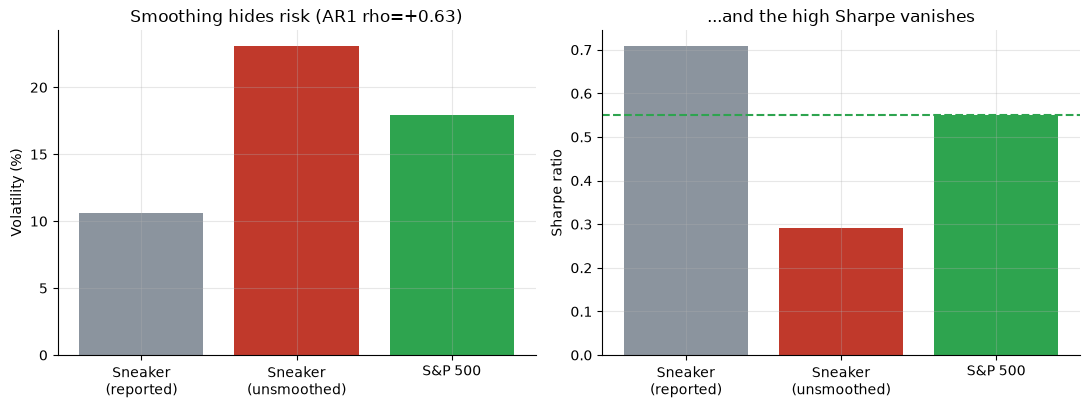

Reported sneaker Sharpe: 0.71 (> S&P 0.55) -- looks great
Unsmoothed sneaker Sharpe: 0.29 (< S&P 0.55) -- the edge is gone


In [5]:
if HAVE_REAL:
    rho = s['ar1_rho']; rep_vol = s['sneaker_vol_pct']; uns_vol = s['unsmoothed_vol_pct']
    rep_sh = s['sneaker_sharpe']; uns_sh = s['unsmoothed_sharpe']; spx_sh = s['gspc_sharpe']
else:
    rho = R['ar1_rho']; rep_vol = R['sneaker_vol_pct']; uns_vol = R['unsmoothed_vol_pct']
    rep_sh = R['sneaker_sharpe']; uns_sh = R['unsmoothed_sharpe']; spx_sh = R['gspc_sharpe']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(['Sneaker\n(reported)', 'Sneaker\n(unsmoothed)', 'S&P 500'],
            [rep_vol, uns_vol, R['gspc_vol_pct']], color=[GREY, RED, GREEN])
axes[0].set_ylabel('Volatility (%)'); axes[0].set_title(f'Smoothing hides risk (AR1 rho={rho:+.2f})')
axes[1].bar(['Sneaker\n(reported)', 'Sneaker\n(unsmoothed)', 'S&P 500'],
            [rep_sh, uns_sh, spx_sh], color=[GREY, RED, GREEN])
axes[1].axhline(spx_sh, ls='--', c=GREEN, lw=1.5)
axes[1].set_ylabel('Sharpe ratio'); axes[1].set_title('...and the high Sharpe vanishes')
plt.tight_layout(); plt.show()
print(f'Reported sneaker Sharpe: {rep_sh:.2f} (> S&P {spx_sh:.2f}) -- looks great')
print(f'Unsmoothed sneaker Sharpe: {uns_sh:.2f} (< S&P {spx_sh:.2f}) -- the edge is gone')

The sneaker index's year-to-year autocorrelation is **+0.63** -- a smoking gun for stale, appraisal-style pricing. Real continuously-traded assets have annual autocorrelation near zero. Once we *unsmooth* the series (a standard fix, from private real estate), the 'low' 10.6% volatility balloons to **23%** -- higher than the S&P -- and the impressive Sharpe collapses **below** the index's.

## 5 - The verdict

- **Signal -- None.** Sneakers *underperformed* the S&P by **−2.4%/yr** (t = −0.57). The only thing that looked good -- the high Sharpe -- is a stale-pricing artifact (ρ = +0.63); unsmoothed, the Sharpe is 0.29 vs the S&P's 0.55.
- **Tradability -- Mirage.** There is no investable sneaker index. The only exposure is reselling physical pairs, at 10–15% marketplace fees, with storage, authentication, and no short side. Net of frictions, ~+4.5%/yr.
- **Busted.** A genuine boom and a genuine bust -- but as an asset class that *beats stocks*, the claim is a mirage built on smoothed marks.

## 6 - Could you actually trade it?

Suppose you tried -- buy pairs, resell on StockX. The frictions are enormous, and there is no fund to do it for you.

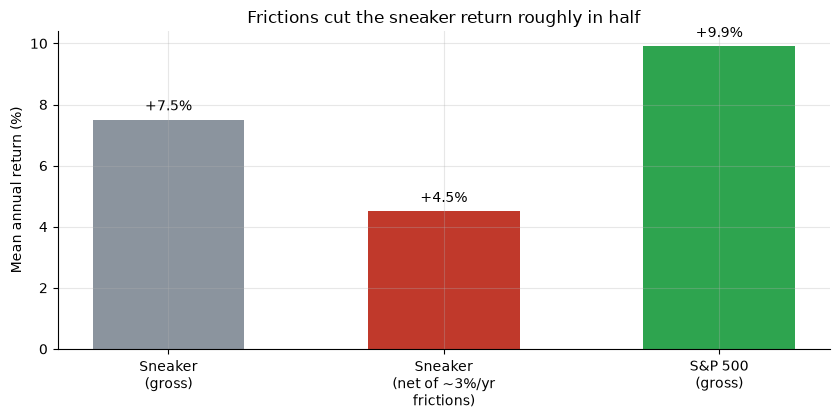

Marketplace seller fees ~10-15%, plus authentication, shipping, storage.
No short side, no index fund. The hustle nets ~half the S&P, gross beats it by nothing.


In [6]:
gross = (s['sneaker_mean_pct'] if HAVE_REAL else R['sneaker_mean_pct'])
net = (s['net_sneaker_mean_pct'] if HAVE_REAL else R['net_sneaker_mean_pct'])
spx = (s['gspc_mean_pct'] if HAVE_REAL else R['gspc_mean_pct'])

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Sneaker\n(gross)', 'Sneaker\n(net of ~3%/yr\nfrictions)', 'S&P 500\n(gross)'],
              [gross, net, spx], color=[GREY, RED, GREEN], width=0.55)
ax.set_ylabel('Mean annual return (%)')
ax.set_title('Frictions cut the sneaker return roughly in half')
for b, v in zip(bars, [gross, net, spx]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v+0.2), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('Marketplace seller fees ~10-15%, plus authentication, shipping, storage.')
print('No short side, no index fund. The hustle nets ~half the S&P, gross beats it by nothing.')

Even before frictions the sneaker index trailed the S&P. After a conservative 3%/yr haircut for marketplace fees and handling, it returns roughly **half** the S&P's gross return -- for far more operational hassle and zero diversification benefit once you account for the true (unsmoothed) risk.

## 7 - Going further

- **The positive control:** the companion notebook plants a real +20–30%/yr sneaker alpha into a synthetic tape and shows the engine detects it cleanly -- so the null result here is about the *market*, not the method.
- **Same illusion, other assets:** smoothed appraisal pricing flatters private real estate, private equity, and many hedge funds -- the Asness-Krail-Liew 'Do Hedge Funds Hedge?' lesson.
- **Collectibles as an asset class:** Dimson & Spaenjers on stamps and wine reach the same verdict -- modest real returns, high costs, illiquidity.

*Think sneakers really beat stocks? Fork this, swap in your own resale index, and show a positive excess return that clears |t| ≥ 2 on the unsmoothed series, net of marketplace fees. That's the bar.*